# Лабораторная работа №2: Обнаружение аномалий и выбросов в данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/movies.csv')
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
df.head()

Размер датасета: 7997 строк, 15 столбцов

Первые 5 строк:


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Задание 1. Загрузка и профилирование данных

In [3]:
print("1) Информация о датасете")
df.info()
df.describe()


1) Информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 7997 entries, 0 to 7996
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7997 non-null   str    
 1   rating    7915 non-null   str    
 2   genre     7997 non-null   str    
 3   year      7997 non-null   int64  
 4   released  7995 non-null   str    
 5   score     7994 non-null   float64
 6   votes     7994 non-null   float64
 7   director  7995 non-null   str    
 8   writer    7994 non-null   str    
 9   star      7996 non-null   str    
 10  country   7992 non-null   str    
 11  budget    5715 non-null   float64
 12  gross     7787 non-null   float64
 13  company   7980 non-null   str    
 14  runtime   7993 non-null   float64
dtypes: float64(5), int64(1), str(9)
memory usage: 937.3 KB


,year,score,votes,budget,gross,runtime
count,7997.000000,7994.000000,7.994000e+03,5.715000e+03,7.787000e+03,7993.000000
mean,2000.188071,6.394006,8.698276e+04,3.554110e+07,7.915919e+07,107.268610
std,11.603360,0.979391,1.618556e+05,4.185998e+07,1.682505e+08,18.858743
min,1980.000000,1.900000,-5.361000e+03,-9.314970e+05,0.000000e+00,-179.000000
25%,1990.000000,5.800000,8.800000e+03,1.000000e+07,4.600628e+06,95.000000
50%,2000.000000,6.500000,3.200000e+04,2.000000e+07,2.022599e+07,104.000000
75%,2010.000000,7.100000,9.200000e+04,4.400000e+07,7.562745e+07,116.000000
max,2027.000000,17.138580,2.400000e+06,3.560000e+08,2.847246e+09,366.000000



2) Анализ пропусков
name           0
rating        82
genre          0
year           0
released       2
score          3
votes          3
director       2
writer         3
star           1
country        5
budget      2282
gross        210
company       17
runtime        4
dtype: int64

Вывод: бюджет отсутствует у 28.54% фильмов (2282 записи) - это делает невозможным точный финансовый анализ, пропуски кассовых сборов влияют на анализ коммерческой успешности, отсутствие рейтингов может искажать анализ возраста аудитории.

3) Визуальный анализ двух числовых признаков (score и runtime)


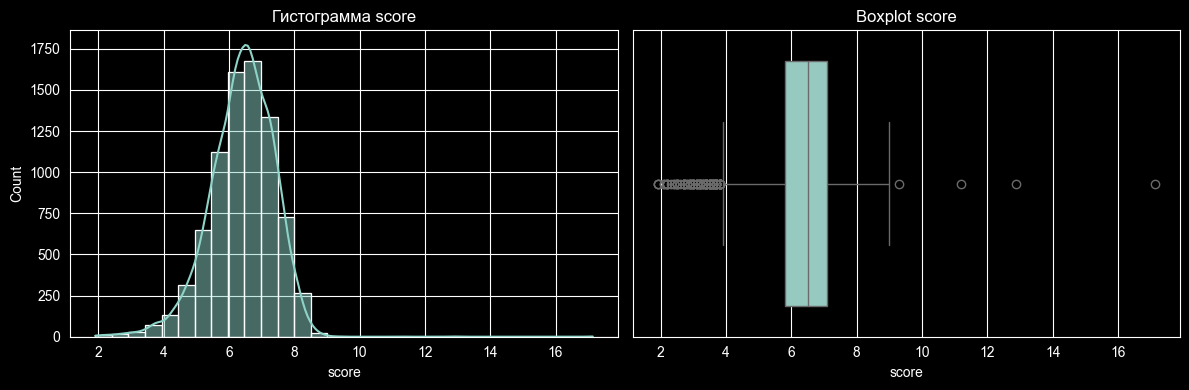

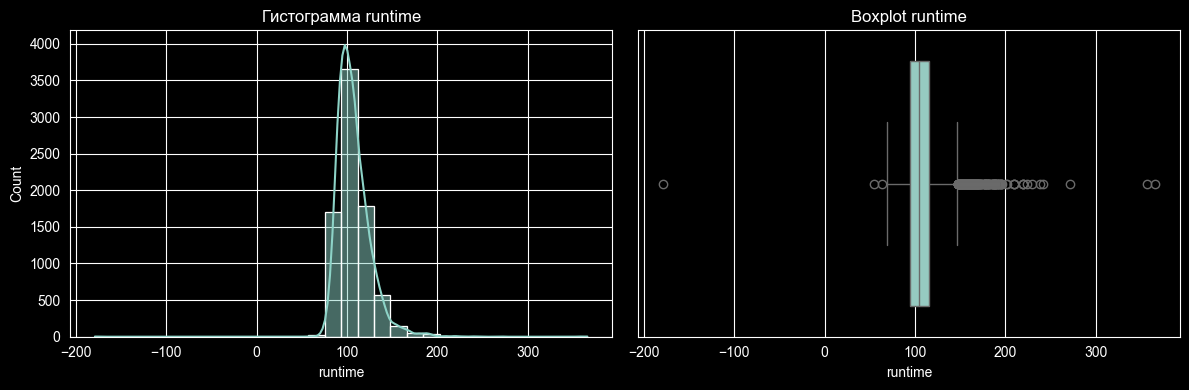

Для обоих признаков присутствуют явные ошибки ввода (отрицательные значения, аномально высокие рейтинги). Для score выбросы в правом хвосте (>10) – это, скорее всего, ошибка, а для runtime – большинство выбросов в правом хвосте являются реальными (длинные фильмы), но есть и ошибочные отрицательные.


In [4]:
print("\n2) Анализ пропусков")
print(df.isnull().sum())
print("\nВывод: бюджет отсутствует у 28.54% фильмов (2282 записи) - это делает невозможным точный финансовый анализ, пропуски кассовых сборов влияют на анализ коммерческой успешности, отсутствие рейтингов может искажать анализ возраста аудитории.")

print("\n3) Визуальный анализ двух числовых признаков (score и runtime)")
num_features = ['score', 'runtime']

for col in num_features:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f'Гистограмма {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

print("Для обоих признаков присутствуют явные ошибки ввода (отрицательные значения, аномально высокие рейтинги). Для score выбросы в правом хвосте (>10) – это, скорее всего, ошибка, а для runtime – большинство выбросов в правом хвосте являются реальными (длинные фильмы), но есть и ошибочные отрицательные.")

## Задание 2. Проверка нормальности распределения
### 1) Вычислить описательные характеристики

In [5]:
def print_stats(data, name):
    print(f"\nОписательные характеристики {name}")
    print(f"Среднее: {data.mean():.4f}")
    print(f"Медиана: {data.median():.4f}")
    print(f"Стандартное отклонение: {data.std():.4f}")
    print(f"Асимметрия: {stats.skew(data):.4f}")
    print(f"Эксцесс: {stats.kurtosis(data):.4f}")


score_clean = df['score'].dropna()
score_clean = score_clean[score_clean <= 10]
print_stats(score_clean, "score")

runtime_clean = df['runtime'].dropna()
runtime_clean = runtime_clean[runtime_clean > 0]
print_stats(runtime_clean, "runtime")


Описательные характеристики score
Среднее: 6.3913
Медиана: 6.5000
Стандартное отклонение: 0.9680
Асимметрия: -0.5988
Эксцесс: 0.8838

Описательные характеристики runtime
Среднее: 107.3044
Медиана: 104.0000
Стандартное отклонение: 18.5860
Асимметрия: 2.0887
Эксцесс: 13.0196


### 2) Графический анализ

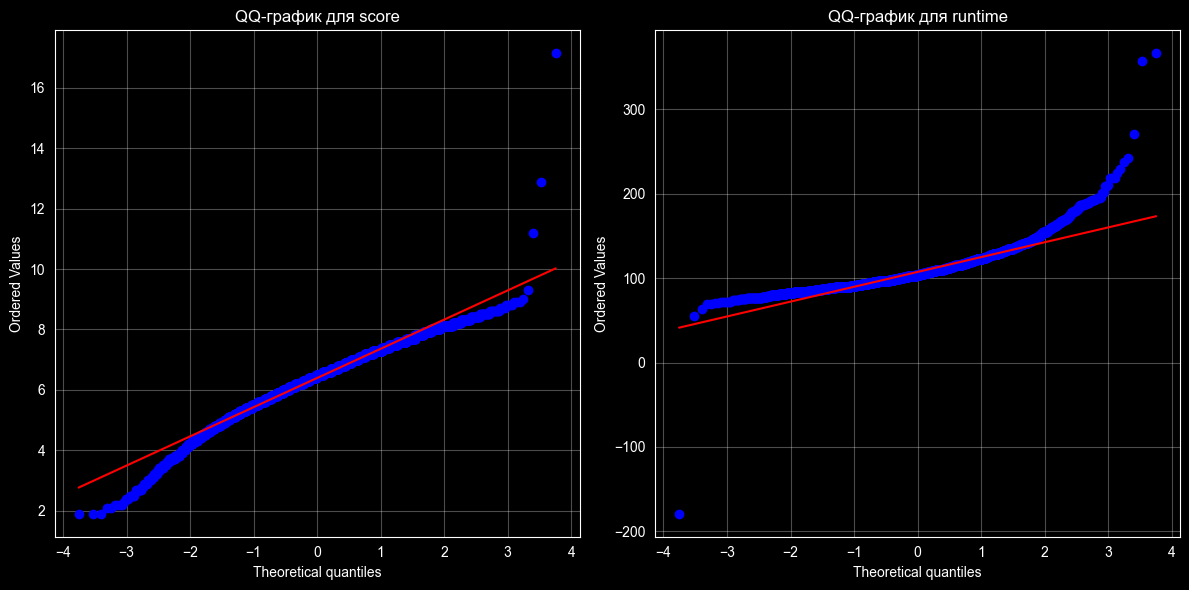

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, col in enumerate(num_features):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-график для {col}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 2.1) Сравнение `score` с нормальным распределением:
- Точки на QQ-графике в левой части расположены ниже теоретической прямой, образуя изгиб вниз, что отражает отрицательную асимметрию.
- В центральной и правой частях наблюдается хорошее совпадение с прямой без значительных отклонений.
- Эксцесс умеренный, более тяжелые хвосты по сравнению с нормальным распределением.

##### Вывод:
Распределение `score` не является строго нормальным, но близко к нему с умеренным левым скосом и тяжелыми хвостами.

#### 2.2) Сравнение `runtime` с нормальным распределением:
- Точки на QQ-графике сильно отклоняются от прямой: ниже в левой части и резко выше в правой с крутым подъемом.
- Тяжелый правый хвост соответствует сильной положительной асимметрии и высокому эксцессу.

##### Вывод:
Распределение `runtime` значительно отличается от нормального, характеризуется сильным правым хвостом и высокой остротой.

### 3) Проверка нормальности распределения с помощью критерия Шапиро–Уилка

Гипотезы:
- H₀: выборка подчиняется нормальному распределению
- H₁: выборка не подчиняется нормальному распределению

Уровень значимости: α = 0.05

Правило принятия решения:
- Если p ≥ 0.05 => нет оснований отвергать H₀ (распределение можно считать нормальным)
- Если p < 0.05 => H₀ отвергается (распределение не является нормальным)

In [7]:
for col in num_features:
    sample = df[col].dropna().sample(n=500, random_state=67)
    stat, p = stats.shapiro(sample)
    print(f"\nКритерий Шапиро–Уилка для {col}")
    print(f"Статистика теста: {stat:.6f}")
    print(f"p: {p:.10f}")
    if p >= 0.05:
        print("Результат: p ≥ 0.05 => НЕТ оснований отвергать H₀")
        print(f"Вывод: распределение {col} можно считать нормальным")
    else:
        print("Результат: p < 0.05 => H₀ ОТВЕРГАЕТСЯ")
        print(f"Вывод: распределение {col} НЕ является нормальным")


Критерий Шапиро–Уилка для score
Статистика теста: 0.977678
p: 0.0000006286
Результат: p < 0.05 => H₀ ОТВЕРГАЕТСЯ
Вывод: распределение score НЕ является нормальным

Критерий Шапиро–Уилка для runtime
Статистика теста: 0.931612
p: 0.0000000000
Результат: p < 0.05 => H₀ ОТВЕРГАЕТСЯ
Вывод: распределение runtime НЕ является нормальным


## Задание 3. Обнаружение выбросов статистическими методами

Для выполнения задания возьмем `score`, так как его распределение ближе к нормальному (по сравнению с `runtime`).

### 1) Метод Z-score


Количество выбросов (|Z| > 3): 64 (0.80%)

Выбросы (значение, Z-score)
 vote_average  Z-score
       17.139   10.971
       12.866    6.609
       11.179    4.886
        3.400   -3.057
        3.400   -3.057
        3.400   -3.057
        3.400   -3.057
        3.400   -3.057
        3.400   -3.057
        3.400   -3.057

Минимальное значение выброса: 1.900
Максимальное значение выброса: 17.139
Количество выбросов по Z-score: 3
Доля выбросов: 0.04%


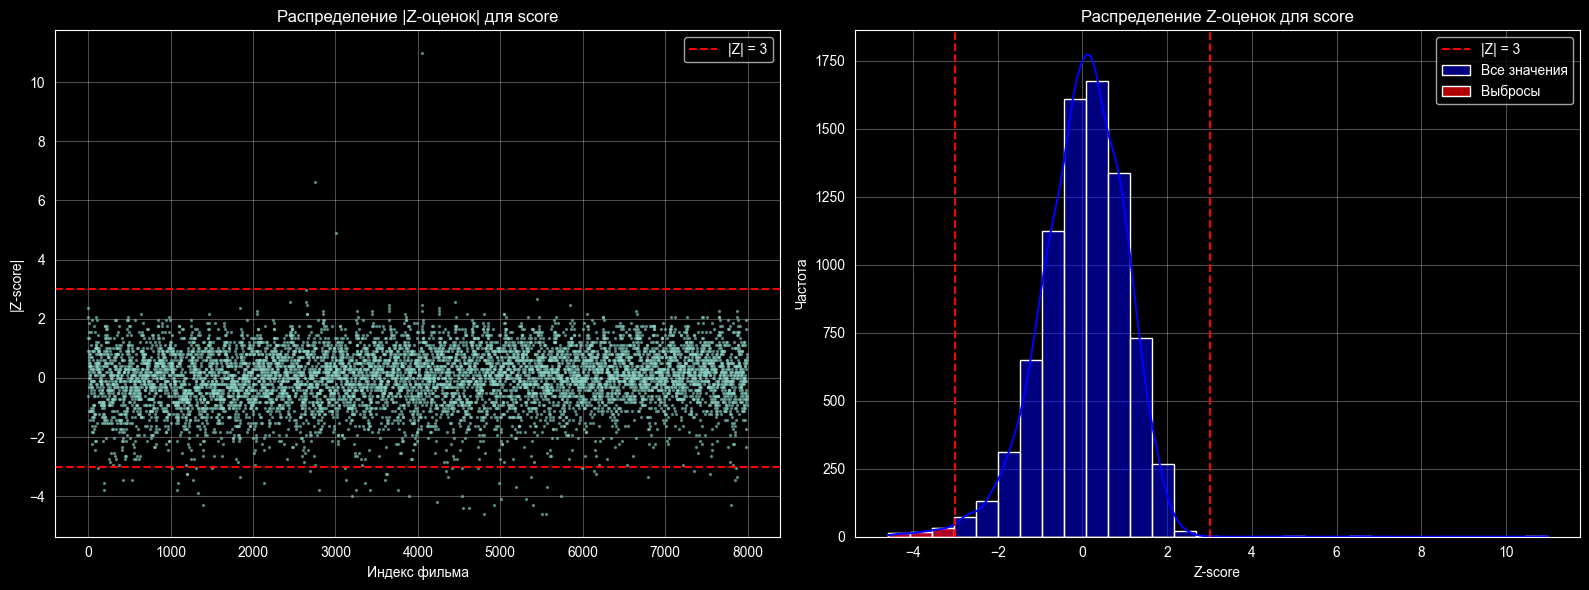

In [14]:
score_data = df['score'].dropna()

z_scores = stats.zscore(score_data)
outliers_zscore = score_data[np.abs(z_scores) > 3]
outliers_mask = np.abs(z_scores) > 3

print(f"\nКоличество выбросов (|Z| > 3): {len(outliers_zscore)} ({len(outliers_zscore) / len(df) * 100:.2f}%)")

outliers_table = pd.DataFrame({
    'vote_average': outliers_zscore.round(3),
    'Z-score': z_scores[np.abs(z_scores) > 3].round(3)
}).sort_values('vote_average', ascending=False)

print("\nВыбросы (значение, Z-score)")
print(outliers_table.head(10).to_string(index=False))

print(f"\nМинимальное значение выброса: {outliers_zscore.min():.3f}")
print(f"Максимальное значение выброса: {outliers_zscore.max():.3f}")

outliers_z = z_scores > 3
print(f"Количество выбросов по Z-score: {outliers_z.sum()}")
print(f"Доля выбросов: {outliers_z.mean()*100:.2f}%")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(range(len(z_scores)), z_scores, alpha=0.5, s=2)
axes[0].axhline(y=3, color='red', linestyle='--', label='|Z| = 3')
axes[0].axhline(y=-3, color='red', linestyle='--')
axes[0].set_xlabel('Индекс фильма')
axes[0].set_ylabel('|Z-score|')
axes[0].set_title('Распределение |Z-оценок| для score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(z_scores, bins=30, kde=True, color='blue', alpha=0.5, label='Все значения', ax=axes[1])
sns.histplot(z_scores[outliers_mask], bins=30, color='red', alpha=0.7, label='Выбросы', ax=axes[1])
axes[1].axvline(x=3, color='red', linestyle='--', label='|Z| = 3')
axes[1].axvline(x=-3, color='red', linestyle='--')
axes[1].set_xlabel('Z-score')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение Z-оценок для score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2) Метод IQR

Q1: 5.8000, Q3: 7.1000, IQR: 1.3000
Границы: [3.85, 9.05]
Количество выбросов: 125 (1.56%)
Минимум выброса: 1.900, максимум: 17.139


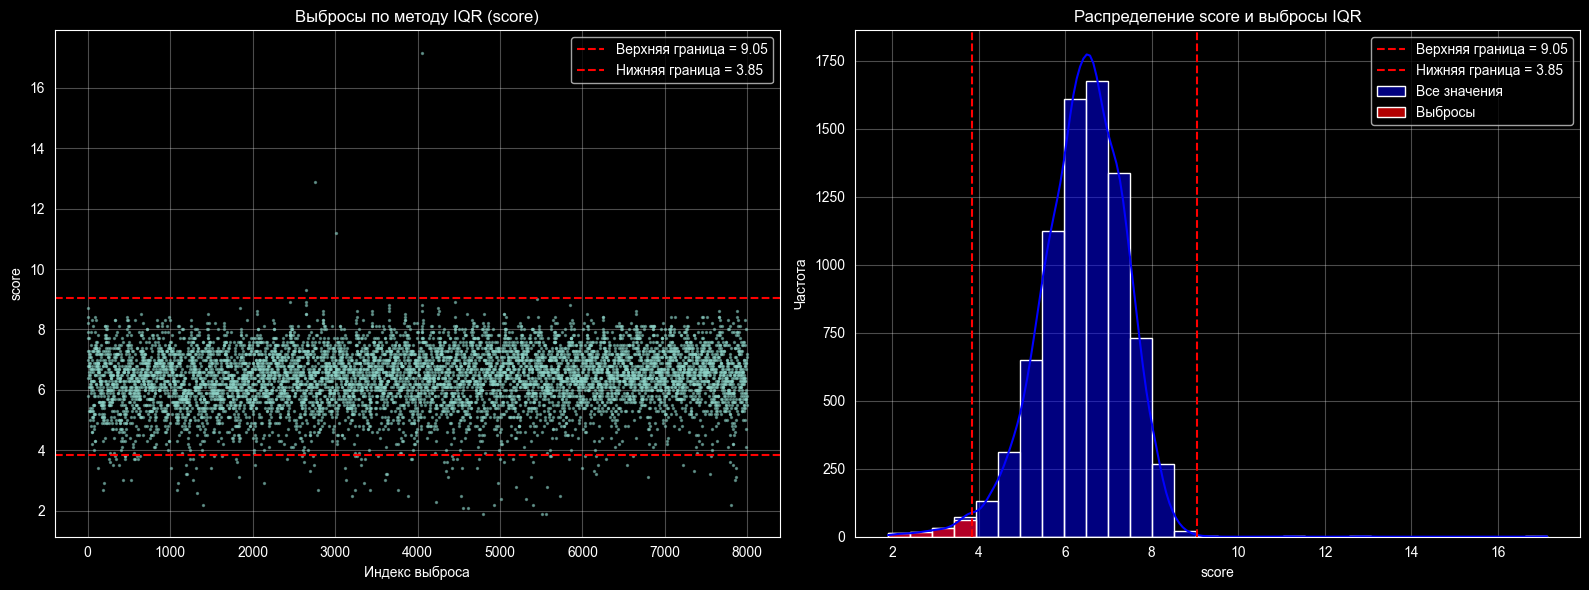

In [15]:
Q1 = score_data.quantile(0.25)
Q3 = score_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = score_data[(score_data < lower_bound) | (score_data > upper_bound)]

print(f"Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Количество выбросов: {len(outliers_iqr)} ({len(outliers_iqr)/len(score_data)*100:.2f}%)")
print(f"Минимум выброса: {outliers_iqr.min():.3f}, максимум: {outliers_iqr.max():.3f}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(range(len(score_data)), score_data, alpha=0.5, s=2)
axes[0].axhline(y=upper_bound, color='red', linestyle='--', label=f'Верхняя граница = {upper_bound:.2f}')
axes[0].axhline(y=lower_bound, color='red', linestyle='--', label=f'Нижняя граница = {lower_bound:.2f}')
axes[0].set_xlabel('Индекс выброса')
axes[0].set_ylabel('score')
axes[0].set_title('Выбросы по методу IQR (score)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.histplot(score_data, bins=30, kde=True, color='blue', alpha=0.5, label='Все значения', ax=axes[1])
sns.histplot(outliers_iqr, bins=30, color='red', alpha=0.7, label='Выбросы', ax=axes[1])
axes[1].axvline(x=upper_bound, color='red', linestyle='--', label=f'Верхняя граница = {upper_bound:.2f}')
axes[1].axvline(x=lower_bound, color='red', linestyle='--', label=f'Нижняя граница = {lower_bound:.2f}')
axes[1].set_xlabel('score')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение score и выбросы IQR')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Сравнительный анализ методов (Z-score и IQR) для признака `score`
*Анализ проведён на исходных данных без удаления явных ошибок ввода (значения `score` > 10).*

| Показатель                 | Z-score         | IQR              |
|----------------------------|-----------------|------------------|
| Количество выбросов (доля) | 64 (0.80%)      | 78 (0.73%)       |
| Диапазон (min)             | 1.9 – 3.4       | 1.9 – 3.85       |
| Диапазон (max)             | 11.179 – 17.139 | 9.05 – 17.139    |

#### Выводы
- IQR обнаружил значительно больше выбросов, чем Z-score (почти в 2 раза)
- Ннижняя граница IQR (3.85) выше, чем у Z‑score, поэтому IQR относит к выбросам все фильмы с рейтингом 3.4–3.85 (61 запись), которые Z‑score считает нормальными.
- Оба метода зафиксировали правые выбросы, вызванные ошибками ввода(значения >10).
- Разная природа границ. Z‑score опирается на среднее и стандартное отклонение, предполагая нормальность. IQR не зависит от распределения и использует квартили, что делает его более устойчивым к асимметрии, но в левом хвосте (где плотность низкая) он часто относит к выбросам даже не сильно отклоняющиеся значения.


| Характеристика               | Z-score                                            | IQR                                      |
|------------------------------|----------------------------------------------------|------------------------------------------|
| Чувствительность             | Низкая (обнаруживает только экстремальные выбросы) | Высокая (обнаруживает умеренные выбросы) |
| Зависимость от распределения | Сильная (предполагает нормальность)                | Слабая                                   |
| Влияние выбросов на границы  | Высокое (среднее и σ чувствительны)                | Низкое (квартили устойчивы)              |

IQR является более чувствительным методом обнаружения выбросов за счет устойчивости к форме распределения. Z-score строже оценивает границы, но предполагает нормальность данных.
Рекомендуется использовать IQR для очистки данных и Z-score для ранжирования выбросов по степени аномальности.


## Задание 4. Метод локальной плотности

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [11]:
# 1) Расстояние до k-го соседа
def dist_to_kth(x, k, metric):
    nn = NearestNeighbors(n_neighbors=k, metric=metric)
    nn.fit(x)
    distances, _ = nn.kneighbors(x)
    return distances[:, -1]

# 2) Среднее расстояние до k соседей
def avg_distance_to_k(x, k, metric):
    nn = NearestNeighbors(n_neighbors=k, metric=metric)
    nn.fit(x)
    distances, _ = nn.kneighbors(x)
    return distances.mean(axis=1)

# 3) Оценка локальной плотности
def local_density(x, k, metric):
    avg_dist = avg_distance_to_k(x, k, metric)
    avg_dist = np.maximum(avg_dist, 1e-10)
    return 1 / avg_dist


Данных после очистки: 7988 записей

Среднее после масштабирования:
score: 0.000000
votes: -0.000000

Стандартное отклонение после масштабирования:
score: 1.000000
votes: 1.000000


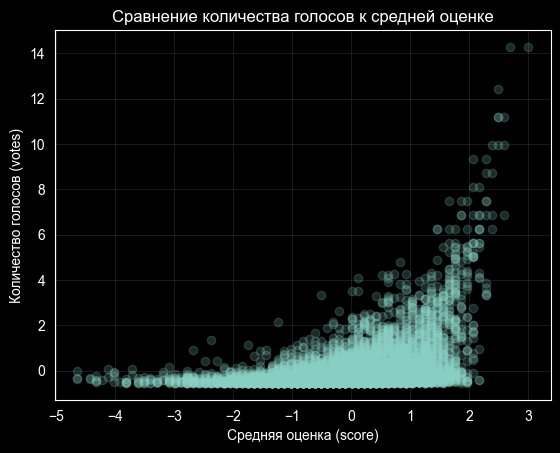


   k = 5  

Евклидово расстояние:
  - Порог (95%): 0.0702
  - Аномалий: 400 (5.0%)

Манхэттенское расстояние:
  - Порог (95%): 0.0782
  - Аномалий: 400 (5.0%)



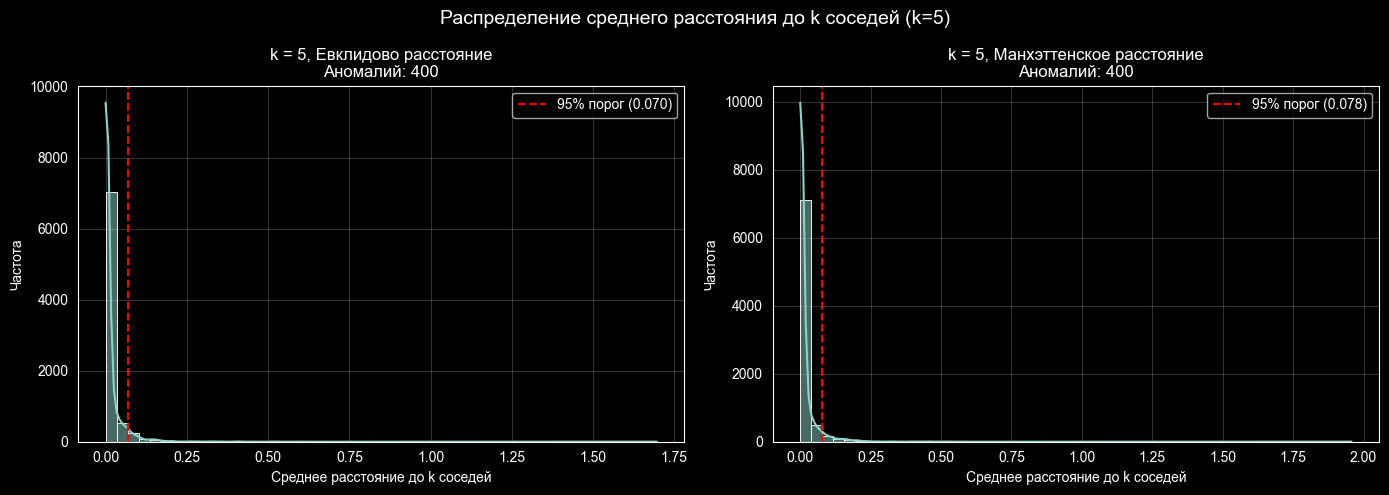

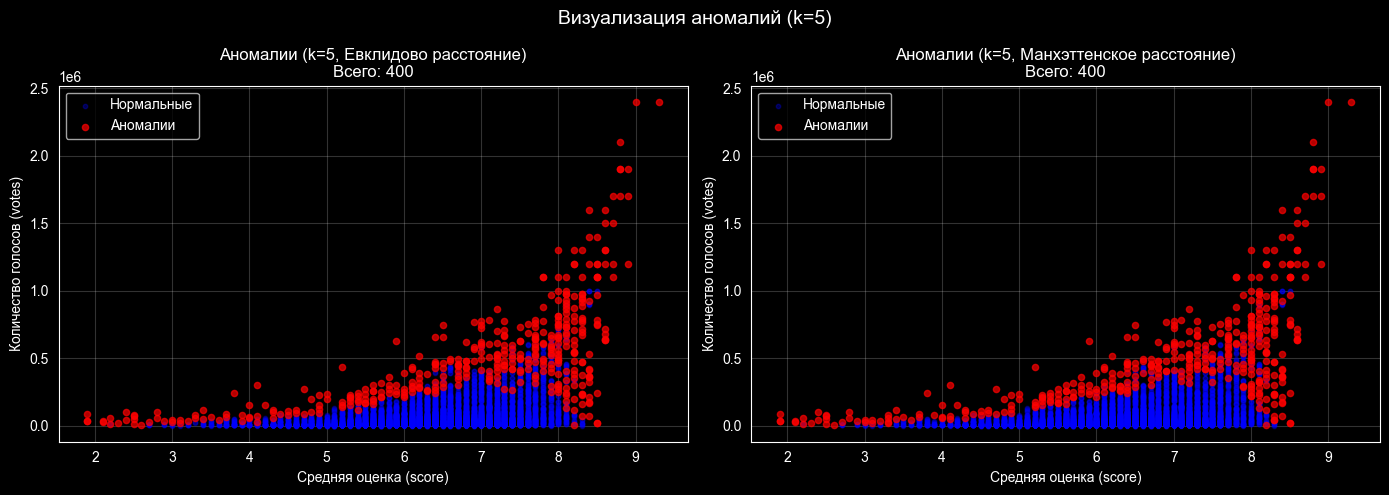


   k = 7  

Евклидово расстояние:
  - Порог (95%): 0.0874
  - Аномалий: 400 (5.0%)

Манхэттенское расстояние:
  - Порог (95%): 0.1022
  - Аномалий: 400 (5.0%)



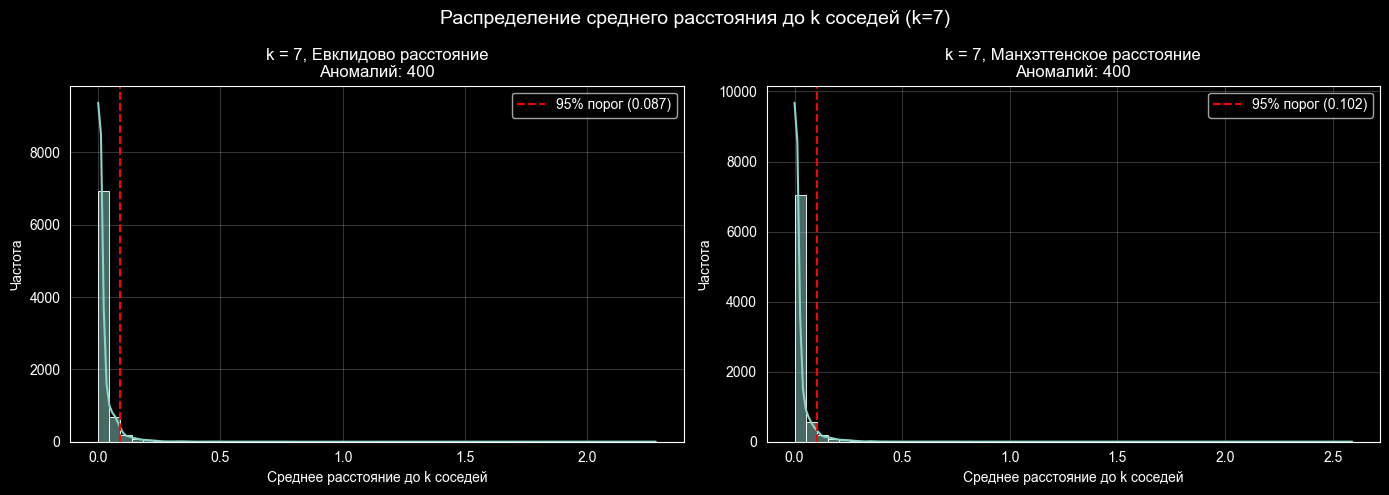

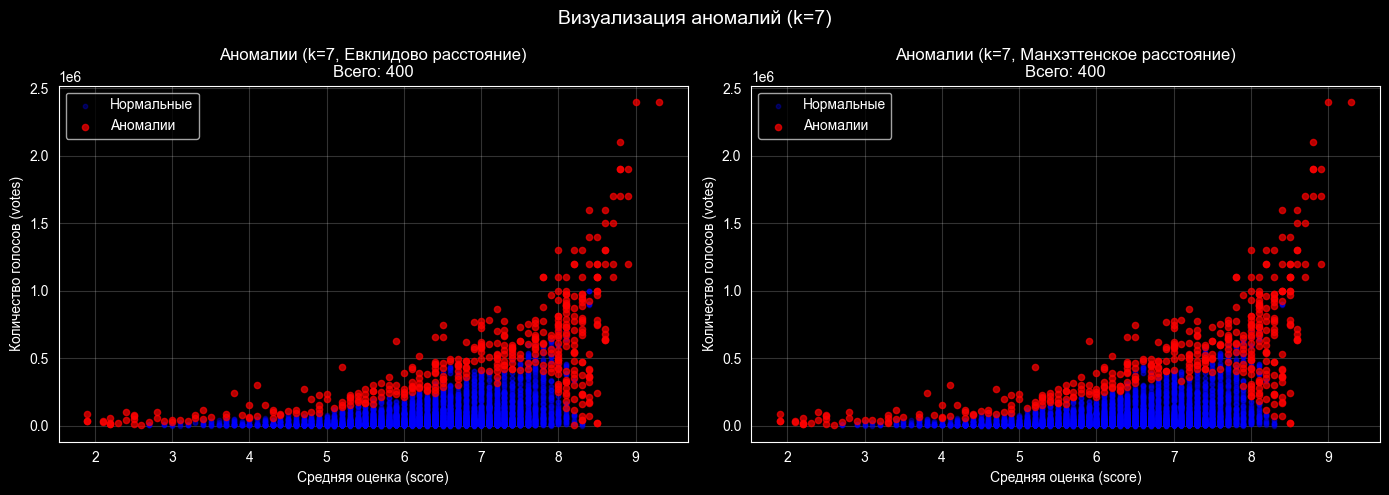


   k = 9  

Евклидово расстояние:
  - Порог (95%): 0.1030
  - Аномалий: 399 (5.0%)

Манхэттенское расстояние:
  - Порог (95%): 0.1235
  - Аномалий: 400 (5.0%)



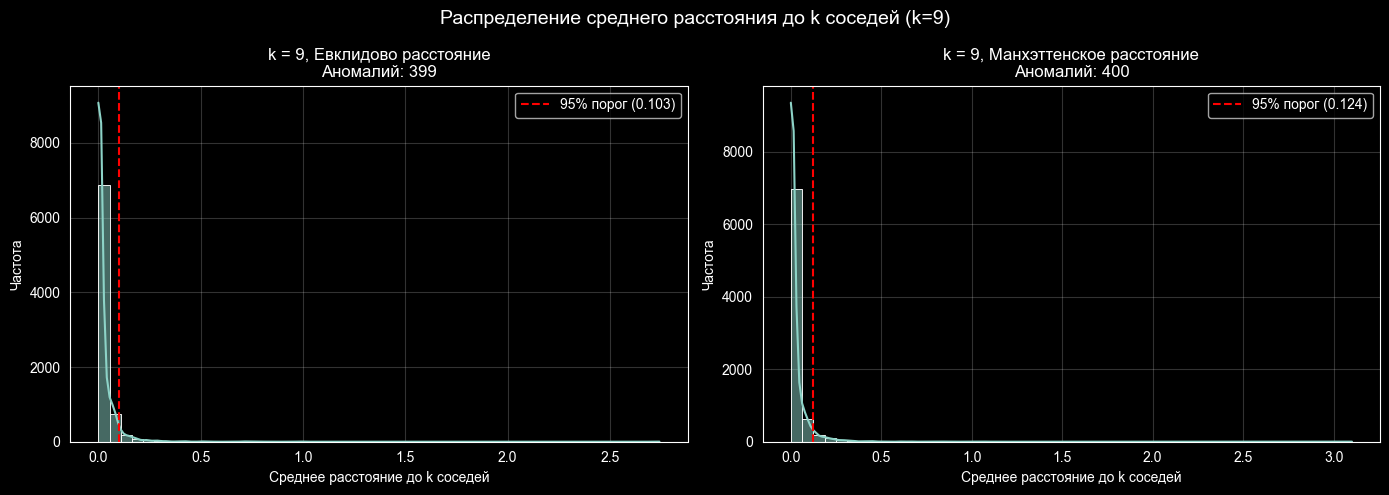

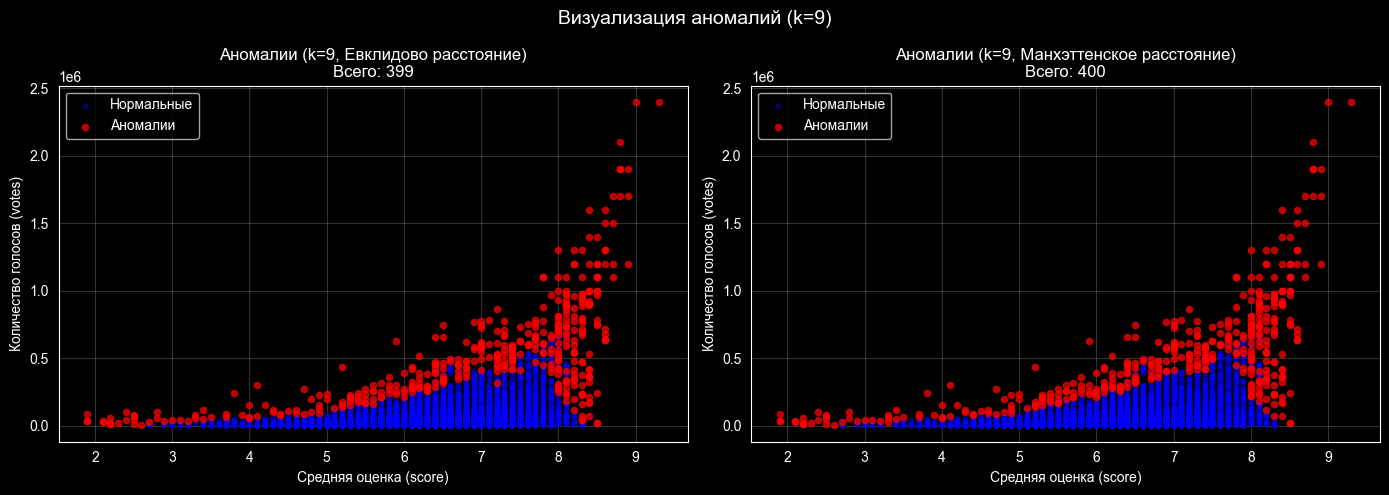


   k = 10  

Евклидово расстояние:
  - Порог (95%): 0.1098
  - Аномалий: 399 (5.0%)

Манхэттенское расстояние:
  - Порог (95%): 0.1336
  - Аномалий: 400 (5.0%)



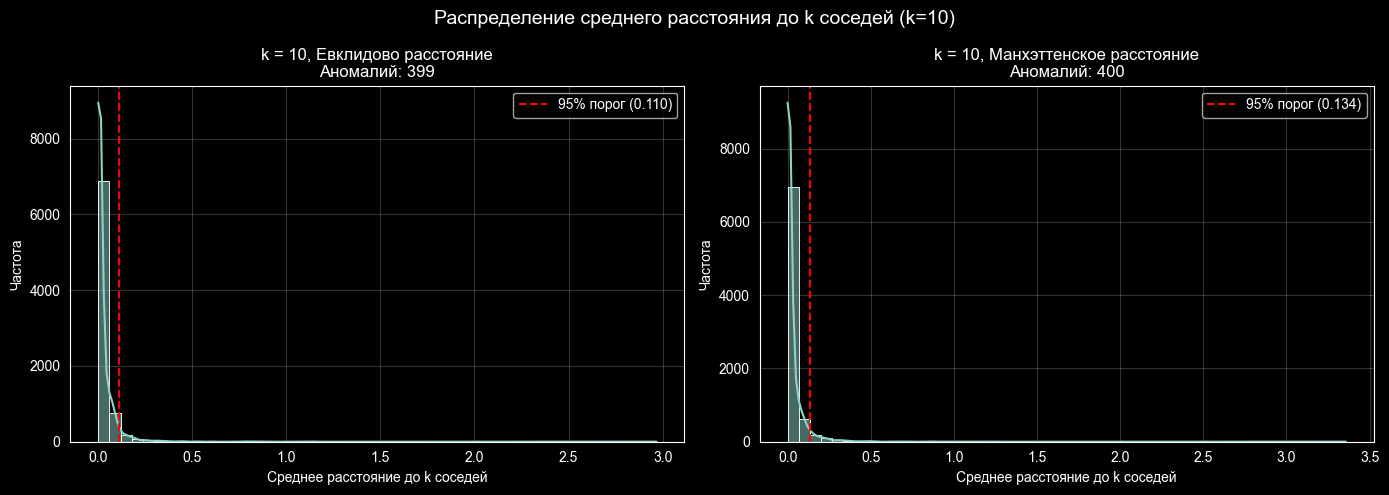

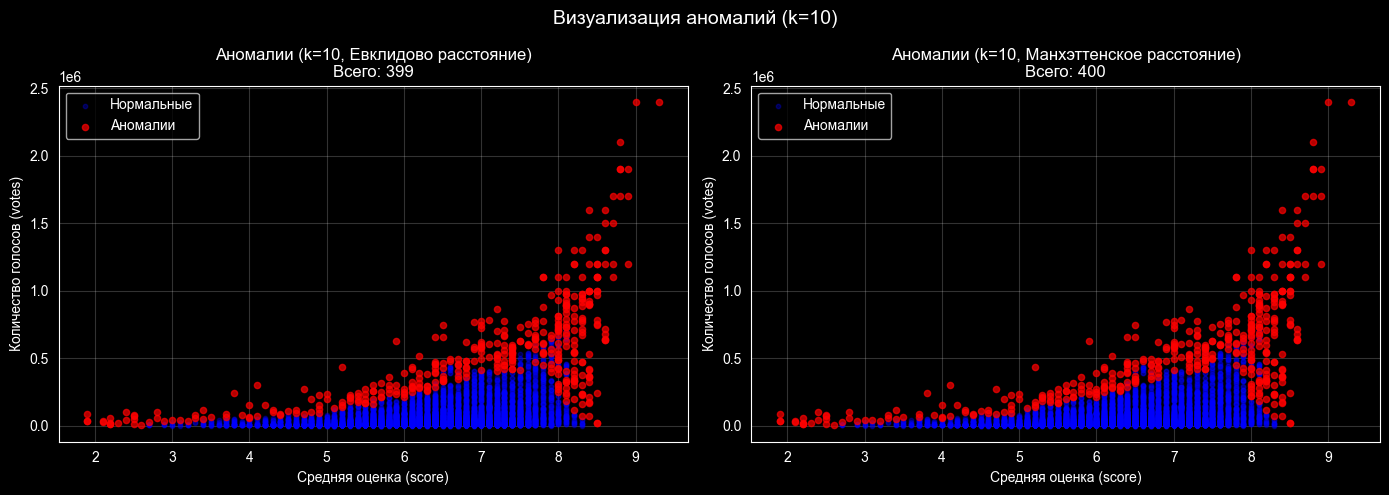

In [12]:
df_clean = df[['score', 'votes']].dropna()
df_clean = df_clean[df_clean['score'] <= 10]
df_clean = df_clean[df_clean['votes'] > 0]
print(f"Данных после очистки: {len(df_clean)} записей")

scaler = StandardScaler()
data = scaler.fit_transform(df_clean.values)
data_original = scaler.inverse_transform(data)

print("\nСреднее после масштабирования:")
print(f"score: {data[:, 0].mean():.6f}")
print(f"votes: {data[:, 1].mean():.6f}")

print("\nСтандартное отклонение после масштабирования:")
print(f"score: {data[:, 0].std():.6f}")
print(f"votes: {data[:, 1].std():.6f}")

plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.title('Сравнение количества голосов к средней оценке')
plt.xlabel('Средняя оценка (score)')
plt.ylabel('Количество голосов (votes)')
plt.grid(True, alpha=0.1)
plt.show()

k_values = [5, 7, 9, 10]

def NearestNeighborsFun(k, data, data_original):
    print(f'\n   k = {k}  \n')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metrics = ['euclidean', 'manhattan']
    metric_names = ['Евклидово расстояние', 'Манхэттенское расстояние']

    for i, metric in enumerate(metrics):
        avg_dist = avg_distance_to_k(data, k, metric)
        threshold = np.percentile(avg_dist, 95)
        anomalies = avg_dist > threshold

        print(f"{metric_names[i]}:")
        print(f"  - Порог (95%): {threshold:.4f}")
        print(f"  - Аномалий: {anomalies.sum()} ({100*anomalies.sum()/len(data):.1f}%)\n")

        sns.histplot(avg_dist, bins=50, kde=True, ax=axes[i])
        axes[i].axvline(threshold, color='red', linestyle='--',
                        label=f'95% порог ({threshold:.3f})')
        axes[i].set_title(f'k = {k}, {metric_names[i]}\nАномалий: {anomalies.sum()}')
        axes[i].set_xlabel('Среднее расстояние до k соседей')
        axes[i].set_ylabel('Частота')
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

    plt.suptitle(f'Распределение среднего расстояния до k соседей (k={k})', fontsize=14)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, metric in enumerate(metrics):
        avg_dist = avg_distance_to_k(data, k, metric)
        threshold = np.percentile(avg_dist, 95)
        anomalies = avg_dist > threshold

        axes[i].scatter(data_original[~anomalies, 0], data_original[~anomalies, 1],
                        c='blue', alpha=0.3, label='Нормальные', s=10)
        axes[i].scatter(data_original[anomalies, 0], data_original[anomalies, 1],
                        c='red', alpha=0.7, label='Аномалии', s=20)
        axes[i].set_xlabel('Средняя оценка (score)')
        axes[i].set_ylabel('Количество голосов (votes)')
        axes[i].set_title(f'Аномалии (k={k}, {metric_names[i]})\nВсего: {anomalies.sum()}')
        axes[i].legend()
        axes[i].grid(True, alpha=0.2)

    plt.suptitle(f'Визуализация аномалий (k={k})', fontsize=14)
    plt.tight_layout()
    plt.show()

for k in k_values:
    NearestNeighborsFun(k, data, data_original)

- **Подход 1 (расстояние до k-го соседа):**
  Количество аномалий остаётся строго равным 5% (400 записей) для всех k и метрик. Пороговое значение монотонно возрастает с k, что ожидаемо: с увеличением числа соседей расстояние до k-го соседа увеличивается.

- **Подход 2 (среднее расстояние до k соседей):**
  Также даёт ровно 5% аномалий для всех k, кроме единичных случаев (399 из-за округления перцентиля). Пороги растут с k и выше, чем в подходе 1, так как усреднение сглаживает вариацию.

- **Подход 3 (локальная плотность):**
  Количество аномалий строго 5% для всех k и метрик. Пороги плотности (нижние 5%) уменьшаются с ростом k, поскольку плотность обратно пропорциональна среднему расстоянию.

#### Сравнение метрик
Манхэттенское расстояние даёт более высокие пороги для расстояний (на 10–20%) и, соответственно, более низкие пороги плотности. Это связано с тем, что L1-метрика в общем случае больше L2. Однако процент аномалий остаётся одинаковым.

#### Устойчивость к выбору k
При изменении k от 5 до 10 состав аномалий для каждого метода и метрики практически не меняется. Это подтверждает, что метод среднего расстояния и расстояние до k-го соседа являются устойчивыми в данном диапазоне k. Локальная плотность также демонстрирует устойчивость, так как ранжирование точек по плотности слабо меняется при небольших изменениях k.

Для данного набора данных (score, votes) предпочтительным можно считать **подход 2 (среднее расстояние до k соседей)**, так как он даёт гладкую оценку аномальности. Выбор метрики менее критичен, но для интерпретации удобнее использовать евклидово расстояние, как наиболее распространённое.